In [5]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
X = pd.read_csv('../../data/processed/normalized_best_features.csv', index_col=0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
n_pcs_list = list(range(2, 9))
n_clusters_list = list(range(2, 9))

aic_matrix = np.zeros((len(n_pcs_list), len(n_clusters_list)))
bic_matrix = np.zeros_like(aic_matrix)

for i, n_pcs in enumerate(n_pcs_list):
    pca = PCA(n_components=n_pcs, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    for j, k in enumerate(n_clusters_list):
        gmm = GaussianMixture(
            n_components=k,
            covariance_type="full",
            random_state=42,
            n_init=5
        )
        gmm.fit(X_pca)
        aic_matrix[i, j] = gmm.aic(X_pca)
        bic_matrix[i, j] = gmm.bic(X_pca)


aic_df = pd.DataFrame(aic_matrix, index=n_pcs_list, columns=n_clusters_list)
bic_df = pd.DataFrame(bic_matrix, index=n_pcs_list, columns=n_clusters_list)
aic_df.index.name = "n_PCs"
aic_df.columns.name = "K"
bic_df.index.name = "n_PCs"
bic_df.columns.name = "K"

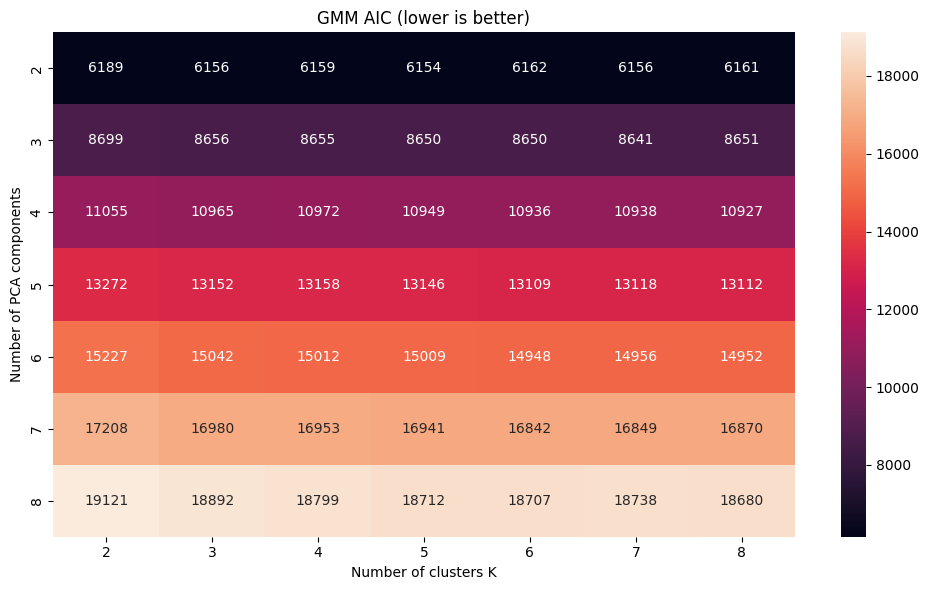

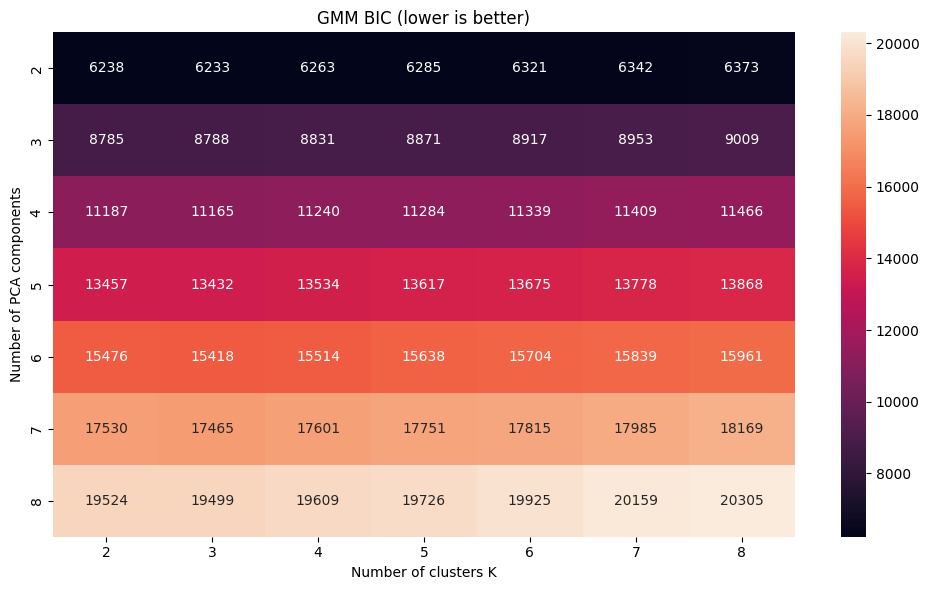

In [7]:
plt.figure(figsize=(10, 6))
sns.heatmap(aic_df, annot=True, fmt=".0f")
plt.title("GMM AIC (lower is better)")
plt.ylabel("Number of PCA components")
plt.xlabel("Number of clusters K")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(bic_df, annot=True, fmt=".0f")
plt.title("GMM BIC (lower is better)")
plt.ylabel("Number of PCA components")
plt.xlabel("Number of clusters K")
plt.tight_layout()
plt.show()